In [6]:
%load_ext autoreload
%autoreload 2

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from saqc import SaQC
import metpyqc as qc

from qc_func import *
from visualizaion_func import *

In [8]:
import sqlalchemy as sa
from sqlalchemy.orm import Session
from crmprtd import setup_logging
from pycds import Station, History

save_path = './comparison_forms/'

db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

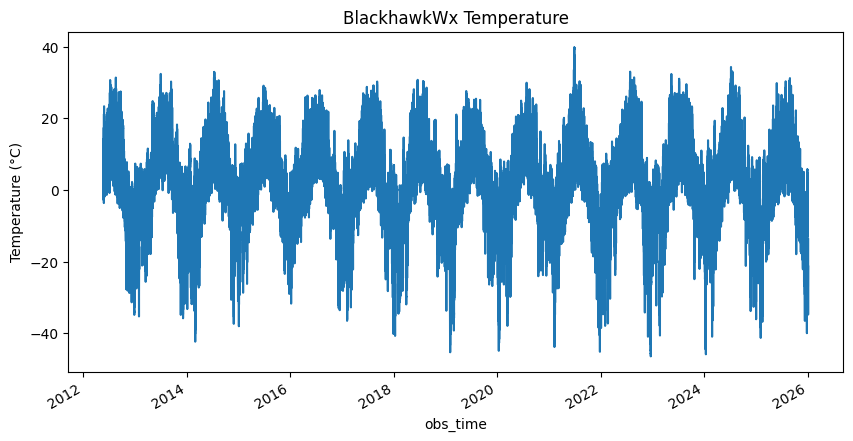

In [ ]:
sql_text = sa.text("""
SELECT Distinct o.obs_time, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 11
AND h.station_name = 'BlackhawkWx'
AND v.net_var_name = 'TempC'
""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)


# convert to datetime
df["obs_time"] = pd.to_datetime(df["obs_time"])

# set as index
df = df.set_index("obs_time").sort_index()

# plot
df["datum"].plot(figsize=(10,5))
plt.ylabel("Temperature (°C)")
plt.title("BlackhawkWx Temperature")
plt.show()


### Missing value check

In [118]:
miss_result = check_missing_timestamps(df)

In [122]:
miss_result['missing_times']

DatetimeIndex(['2015-08-20 09:00:00', '2015-08-20 10:00:00',
               '2015-08-20 11:00:00', '2015-08-20 12:00:00',
               '2016-10-26 10:00:00', '2016-10-26 11:00:00',
               '2016-10-26 12:00:00', '2016-10-26 13:00:00',
               '2022-07-14 09:00:00', '2024-07-18 09:00:00',
               '2025-07-24 09:00:00'],
              dtype='datetime64[us]', freq=None)

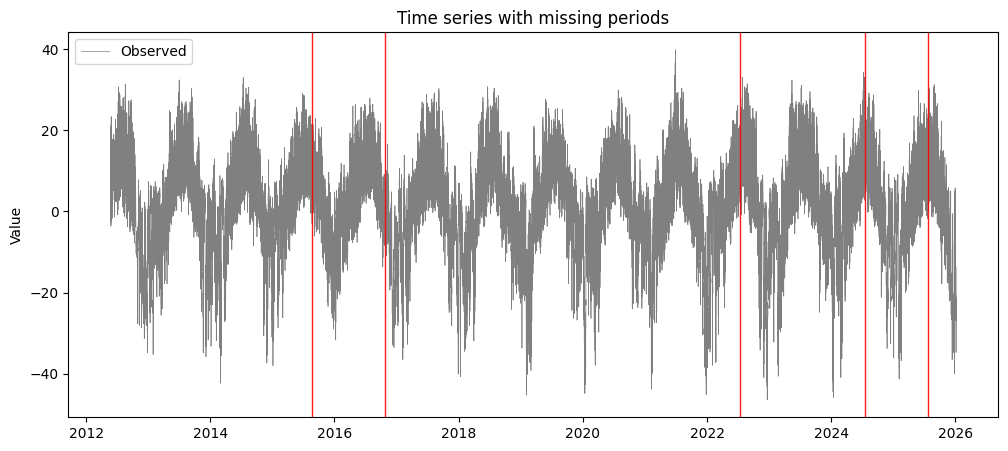

In [144]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_full.index, df_full.iloc[:,0], color='gray', lw=0.5, label='Observed')

# If you have consecutive missing periods:
missing_mask = df_full.iloc[:,0].isna()
groups = (missing_mask != missing_mask.shift()).cumsum()

for _, g in df_full.groupby(groups):
    if g.iloc[:,0].isna().all():
        ax.axvspan(
            g.index.min(),
            g.index.max(),
            color='red',
            alpha=0.9,
            lw = 1,
            zorder = 2
        )

ax.set_title("Time series with missing periods")
ax.set_ylabel("Value")
ax.legend()
plt.show() 

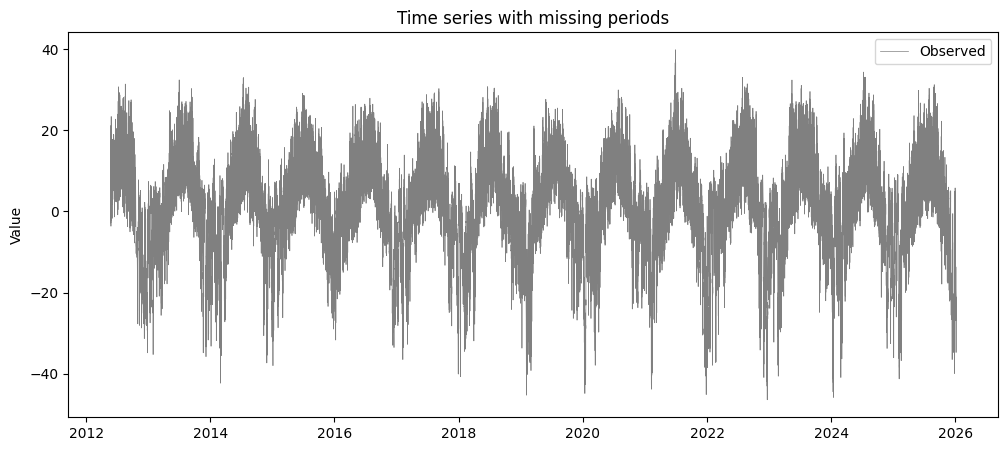

In [143]:
plot_missing_periods(df, title="Time series with missing periods", 
                         series_label="Observed", color_series="gray", 
                         color_missing="red", alpha_missing=0.9, figsize=(12,5))

### Duplicate check

### Out of range check

In [ ]:
qc = qc_range_check(df, min_val=-30, max_val=30)
flag = qc["flag"]
dev  = qc["deviation"]

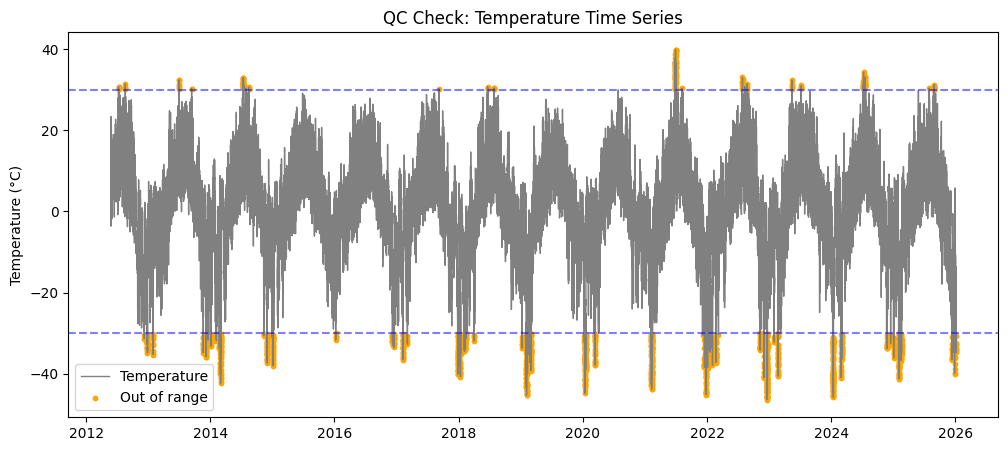

In [76]:
def plot_out_range(df, min_val=-30, max_val=30, flag=None):
    fig, ax = plt.subplots(figsize=(12,5))

    # main line
    ax.plot(df.index, df.iloc[:,0], color='gray', linewidth=1, label="Temperature")

    # out-of-range points
    if flag is not None:
        mask = flag.iloc[:,0] == 1
        ax.scatter(
            df.index[mask],
            df.iloc[:,0][mask],
            color='orange',
            s=10,
            label="Out of range"
        )


    ax.axhline(min_val, linestyle="--", color="blue", alpha=0.5)
    ax.axhline(max_val, linestyle="--", color="blue", alpha=0.5)

    ax.set_ylabel("Temperature (°C)")
    ax.set_title("QC Check: Temperature Time Series")
    ax.legend()

    plt.show()

plot_out_range(df, flag=flag)

In [77]:
print("Out-of-range:", flag.sum().values[0])


Out-of-range: 1689
